#**Instagram Reach Prediction**

#Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error

In [ ]:
df=pd.read_csv("instagram_reach.csv")
df.head()

,Unnamed: 0,S.No,USERNAME,Caption,Followers,Hashtags,Time since posted,Likes
0,0,1,mikequindazzi,Who are #DataScientist and what do they do? >>...,1600,#MachineLearning #AI #DataAnalytics #DataScien...,11 hours,139
1,1,2,drgorillapaints,We all know where it’s going. We just have to ...,880,#deck .#mac #macintosh#sayhello #apple #steve...,2 hours,23
2,2,3,aitrading_official,Alexander Barinov: 4 years as CFO in multinati...,255,#whoiswho #aitrading #ai #aitradingteam#instat...,2 hours,25
3,3,4,opensourcedworkplace,sfad,340,#iot #cre#workplace #CDO #bigdata #technology#...,3 hours,49
4,4,5,crea.vision,Ever missed a call while your phone was chargi...,304,#instamachinelearning #instabigdata#instamarke...,3 hours,30


In [ ]:
df.tail()

,Unnamed: 0,S.No,USERNAME,Caption,Followers,Hashtags,Time since posted,Likes
95,8,19,michaelgarza__,"328 S. Wetherly Drive, Beverly Hills, CA 90212...",614,#beverlyhills #realestate#losangelesrealestate...,3 hours,31
96,9,21,dvlp_search,Credit @tristankappel To find more dvlp follow...,450,#workspace #work #developer#development #devel...,3 hours,42
97,10,22,ecom.space,We are coming up with the Best 21 Books that w...,182,#books #book #motivation #inspiration #life#bo...,3 hours,10
98,11,24,lb3enterprises,We’re only paid to move dirt once. It’s not ju...,2039,#heavyequipment #underconstruction#dozer #real...,3 hours,222
99,12,25,palmariusdev,Obtén tu tienda en línea ahora.,741,#marketing #programming#development #desarroll...,3 hours,109


In [ ]:
df = df.drop('Unnamed: 0', axis=1)

In [ ]:
df.head()

,S.No,USERNAME,Caption,Followers,Hashtags,Time since posted,Likes
0,1,mikequindazzi,Who are #DataScientist and what do they do? >>...,1600,#MachineLearning #AI #DataAnalytics #DataScien...,11 hours,139
1,2,drgorillapaints,We all know where it’s going. We just have to ...,880,#deck .#mac #macintosh#sayhello #apple #steve...,2 hours,23
2,3,aitrading_official,Alexander Barinov: 4 years as CFO in multinati...,255,#whoiswho #aitrading #ai #aitradingteam#instat...,2 hours,25
3,4,opensourcedworkplace,sfad,340,#iot #cre#workplace #CDO #bigdata #technology#...,3 hours,49
4,5,crea.vision,Ever missed a call while your phone was chargi...,304,#instamachinelearning #instabigdata#instamarke...,3 hours,30


#EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   S.No               100 non-null    int64 
 1   USERNAME           100 non-null    object
 2   Caption            94 non-null     object
 3   Followers          100 non-null    int64 
 4   Hashtags           100 non-null    object
 5   Time since posted  100 non-null    object
 6   Likes              100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB


In [ ]:
df.describe()

,S.No,Followers,Likes
count,100.000000,100.00000,100.00000
mean,16.240000,961.96000,46.48000
std,7.384286,1014.62567,55.08698
min,1.000000,11.00000,8.00000
25%,10.750000,252.75000,19.00000
50%,16.500000,612.00000,29.00000
75%,22.250000,1197.00000,46.00000
max,30.000000,4496.00000,349.00000


In [ ]:
df.shape

(100, 7)

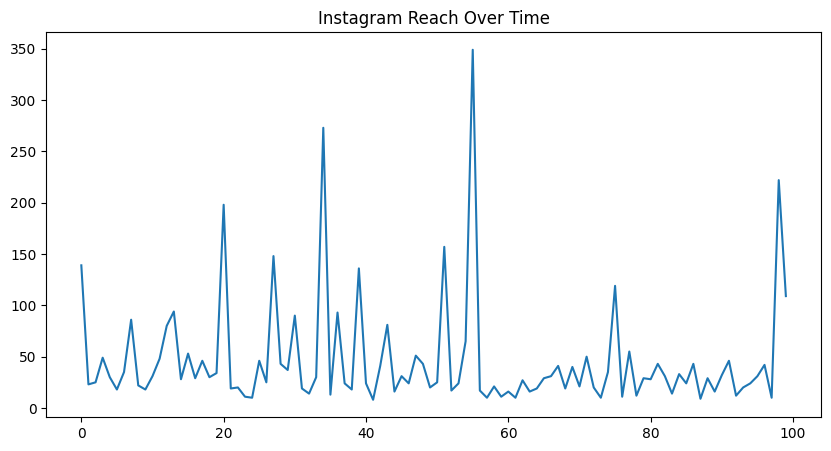

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df['Likes'])
plt.title("Instagram Reach Over Time")
plt.show()

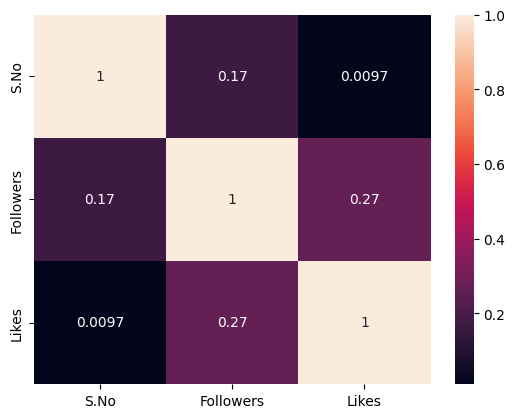

In [ ]:
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True)
plt.show()

#Data Preprocessing

In [ ]:
# Set index
df.set_index('Time since posted', inplace=True)

# Sort data
df = df.sort_index()

# Handle missing values
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_1003/503151069.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


#Checking Trend (By rolling mean)

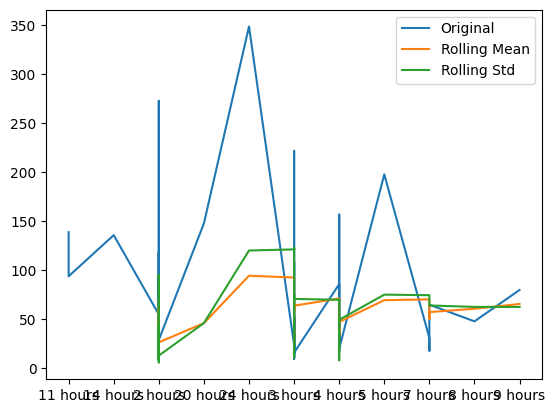

In [ ]:
rolling_mean = df['Likes'].rolling(window=7).mean()
rolling_std = df['Likes'].rolling(window=7).std()

plt.plot(df['Likes'], label='Original')
plt.plot(rolling_mean, label='Rolling Mean')
plt.plot(rolling_std, label='Rolling Std')
plt.legend()
plt.show()

#Adf Test (Stationary Check)

In [ ]:
def adfuller_test(Likes):
    result=adfuller(Likes)
    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']
    for value,label in zip(result,labels):
        print(label+' : '+str(value) )
    if result[1] <= 0.05:
        print("strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")

In [ ]:
  adfuller_test(df['Likes'])

ADF Test Statistic : -9.357149162268195
p-value : 8.002470524702523e-16
#Lags Used : 0
Number of Observations Used : 99
strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary


#ARIMA MODEL

In [ ]:
model = ARIMA(df['Likes'], order=(1,1,1))  # (p,d,q)
model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a 

In [ ]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Likes   No. Observations:                  100
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -539.372
Date:                Fri, 27 Mar 2026   AIC                           1084.743
Time:                        06:35:27   BIC                           1092.529
Sample:                             0   HQIC                          1087.893
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0762      0.101      0.754      0.451      -0.122       0.274
ma.L1         -0.9999      9.349     -0.107      0.915     -19.323      17.323
sigma2      3022.5534   2.82e+04      0.107      0.9

In [ ]:
#Prediction
forecast = model_fit.forecast(steps=10)
print(forecast)

100    49.127637
101    46.776037
102    46.596911
103    46.583267
104    46.582228
105    46.582149
106    46.582143
107    46.582142
108    46.582142
109    46.582142
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


#SARIMA MODEL (Seasonality)

In [ ]:
sarima_model = SARIMAX(df['Likes'],
                      order=(1,1,1),
                      seasonal_order=(1,1,1,7))  # weekly seasonality

sarima_fit = sarima_model.fit()
print(sarima_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a 

                                     SARIMAX Results                                     
Dep. Variable:                             Likes   No. Observations:                  100
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood                -508.712
Date:                           Fri, 27 Mar 2026   AIC                           1027.424
Time:                                   06:35:27   BIC                           1040.033
Sample:                                        0   HQIC                          1032.514
                                           - 100                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0991      0.119      0.830      0.407      -0.135       0.333
ma.L1         -0.9995      3.493     -0.286

In [ ]:
sarima_forecast = sarima_fit.forecast(steps=10)
print(sarima_forecast)

100     41.334440
101     46.621685
102     44.786569
103    119.612043
104     36.942870
105     31.308568
106     44.056891
107     30.578931
108    114.667806
109     39.519596
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Model Evaluation (MSE)

In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(df['Likes'][-10:], forecast)
print("MSE:", mse)

MSE: 2770.3024331593524


Visualisation

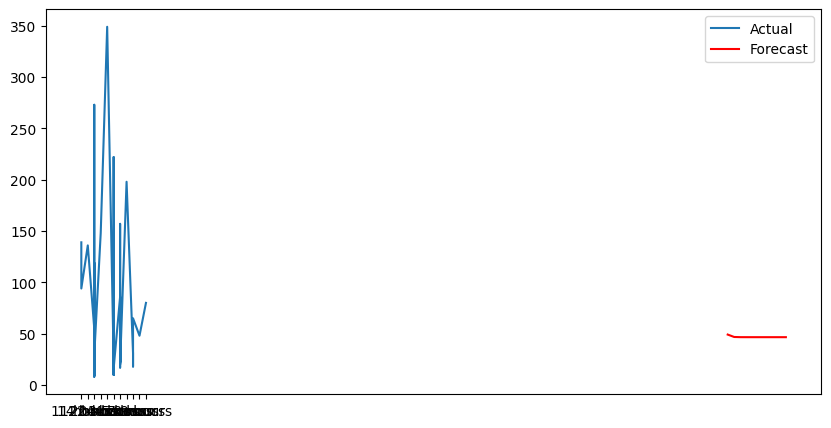

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df['Likes'], label='Actual')
plt.plot(forecast, label='Forecast', color='red')
plt.legend()
plt.show()